In [ ]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 8.5 MB/s eta 0:00:00


# Detección de anomalías
## IQR, Z-score y MAD

In [ ]:
# Importing
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import QuantileTransformer
from itertools import product
from scipy.stats import zscore
from scipy.stats import median_abs_deviation
from pyod.models.mad import MAD# threshold defaults to 3.5
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF


In [ ]:
# Load the dataset
california_data = fetch_california_housing()
target_col = "MedHouseVal"
analysis_col = "MedInc"
# Create the dataframe
df_cal = pd.DataFrame(california_data.data,columns=california_data.feature_names)
df_cal[target_col] = california_data["target"]
series_an = df_cal[analysis_col]
df_cal.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
series_an.describe()

,MedInc
count,20640.000000
mean,3.870671
std,1.899822
min,0.499900
25%,2.563400
50%,3.534800
75%,4.743250
max,15.000100


<Axes: ylabel='Frequency'>

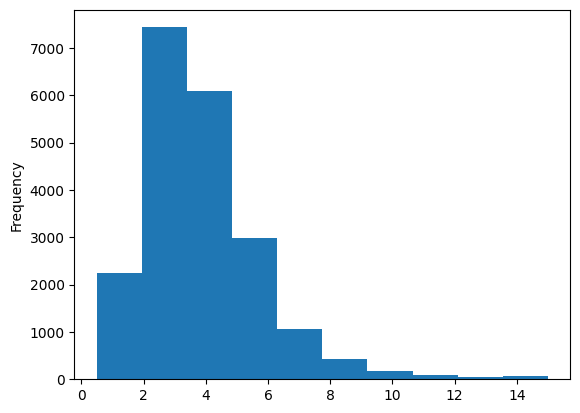

In [ ]:

series_an.plot(kind="hist")

In [ ]:
df_cal.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Text(0.5, 0, 'MedInc')

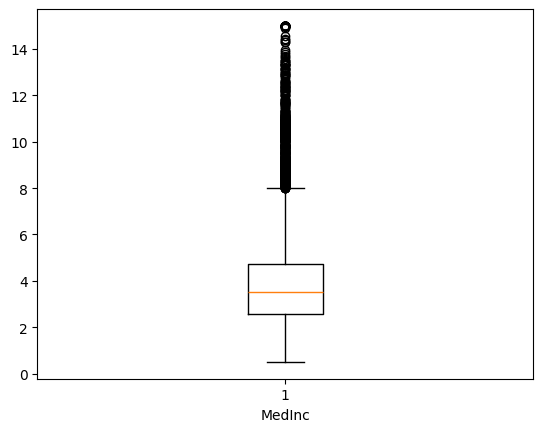

In [ ]:
plt.boxplot(series_an, whis=1.5)
plt.xlabel(analysis_col)


Text(0.5, 0, 'MedInc')

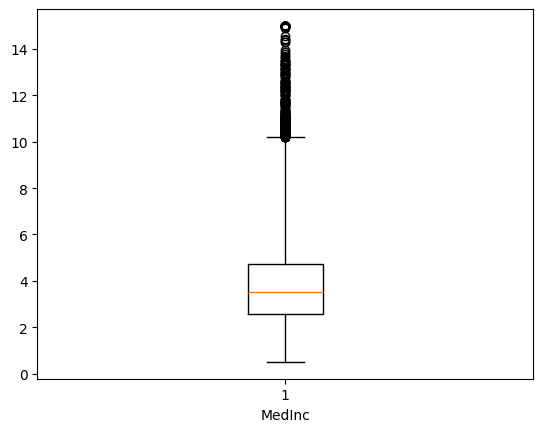

In [ ]:
plt.boxplot(series_an, whis=2.5)
plt.xlabel(analysis_col)


In [ ]:
def get_IQR_limit(series,whis=1.5):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3-Q1
  upper_limit = Q3 + whis*IQR
  lower_limit = Q1 - whis*IQR
  return lower_limit, upper_limit

def get_outliers_IQR(series,whis=1.5):
  lower_limit, upper_limit = get_IQR_limit(series,whis = whis)
  return series[((series<lower_limit) | (series>upper_limit))]

def rm_outliers_IRQ(series,whis=1.5):
  lower_limit, upper_limit = get_IQR_limit(series,whis = whis)
  return series[((series>=lower_limit) & (series<=upper_limit))]


In [ ]:
get_IQR_limit(series_an)


(np.float64(-0.7063750000000004), np.float64(8.013024999999999))

In [ ]:
get_outliers_IQR(series_an, whis=2.5)

,MedInc
131,11.6017
510,11.8603
511,13.4990
512,12.2138
514,12.3804
...,...
18504,15.0001
19006,10.2264
20163,12.6320
20376,10.2614


In [ ]:
rm_outliers_IRQ(series_an)

,MedInc
2,7.2574
3,5.6431
4,3.8462
5,4.0368
6,3.6591
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


In [ ]:

# transformacion a zscore
scores = zscore(series_an)
scores[:5]

array([ 2.34476576,  2.33223796,  1.7826994 ,  0.93296751, -0.012881  ])

In [ ]:
def get_outliers_Zscore(series,stds=3):
  scores = zscore(series)
  return series[scores.abs()>stds]

def rm_outliers_Zscore(series,stds=3):
  scores = zscore(series)
  return series[scores.abs()<=stds]

### Z-SCORE

<Axes: ylabel='Frequency'>

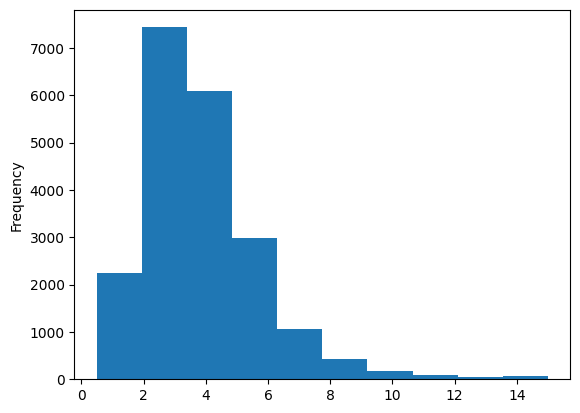

In [ ]:

series_an.plot(kind="hist")

In [ ]:
import numpy as np
from scipy.stats import zscore # Ensure zscore is available

def get_outliers_Zscore(series,stds=3):
  scores = zscore(series)
  return series[np.abs(scores)>stds]

def rm_outliers_Zscore(series,stds=3):
  scores = zscore(series)
  return series[np.abs(scores)<=stds]

get_outliers_Zscore(series_an)

,MedInc
131,11.6017
409,10.0825
510,11.8603
511,13.4990
512,12.2138
...,...
20376,10.2614
20380,10.1597
20389,10.0595
20426,10.0472


In [ ]:
rm_outliers_Zscore(series_an)

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


### MAD

In [ ]:

mad_score = median_abs_deviation(series_an)
mad_score

np.float64(1.0641999999999996)

In [ ]:
mad = MAD(threshold=3.5)# Reshape
series_reshaped = series_an.values.reshape(-1, 1)
labels = mad.fit_predict(series_reshaped)
print("outliers")
series_an[labels==1].describe()

outliers


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


,MedInc
count,400.000000
mean,11.309609
std,1.838279
min,9.068300
25%,10.053200
50%,10.675850
75%,12.369425
max,15.000100


In [ ]:
print("not outliers")
series_an[labels!=1].describe()

not outliers


,MedInc
count,20240.000000
mean,3.723656
std,1.580739
min,0.499900
25%,2.547550
50%,3.500000
75%,4.656300
max,9.051900


In [ ]:
series_an.describe()

,MedInc
count,20640.000000
mean,3.870671
std,1.899822
min,0.499900
25%,2.563400
50%,3.534800
75%,4.743250
max,15.000100


## Isolation Forest

In [ ]:
iforest = IForest()
# lo hacemos con una única variable
series_reshaped = series_an.values.reshape(-1, 1)

labels = iforest.fit_predict(series_reshaped)
outliers = series_an[labels==1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


In [ ]:
outliers.describe()

,MedInc
count,2061.000000
mean,6.386289
std,3.816751
min,0.499900
25%,1.338600
50%,7.302300
75%,8.472100
max,15.000100


Con todo el DF

In [ ]:
# calculamos outliers con todo el dataset
X = df_cal.drop(target_col, axis=1)
y = df_cal[[target_col]]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)


In [ ]:


iforest = IForest()

labels = iforest.fit_predict(X_train)
outliers = X_train[labels==1]
outliers.describe()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,4.823788,23.332687,7.515975,1.469567,1962.589147,4.185445,36.104503,-119.647804
std,3.547906,15.462398,6.463824,1.280602,2579.951349,20.834317,2.678927,2.556758
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.190375,11.000000,4.766398,1.023024,433.750000,2.363525,33.790000,-122.040000
50%,3.521550,19.000000,6.561694,1.098582,926.500000,2.786200,34.860000,-119.050000
75%,6.608225,34.000000,8.258321,1.433333,2550.250000,3.387559,38.250000,-117.380000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,599.714286,41.950000,-114.310000


<Axes: ylabel='x_axis'>

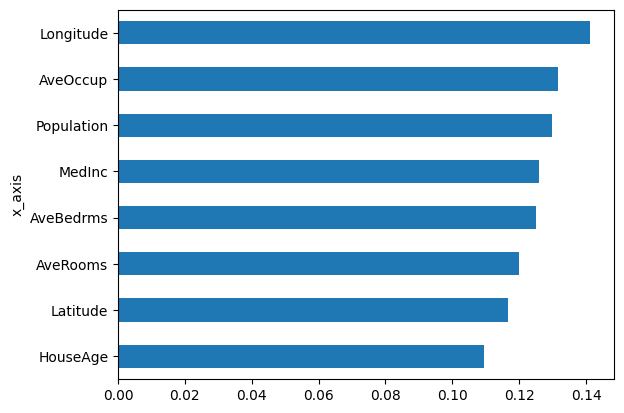

In [ ]:
for_plot = pd.DataFrame({'x_axis':X_train.columns,
              'y_axis':iforest.feature_importances_}).sort_values(by='y_axis',ascending=True).set_index("x_axis")
for_plot['y_axis'].plot.barh()

In [ ]:

iforest = IForest(contamination=0.05,n_estimators=200, max_samples=0.6, max_features=0.9)

labels = iforest.fit_predict(X_train)
outliers = X_train[labels==1]
outliers.describe()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,774.000000,774.000000,774.000000,774.000000,774.000000,774.000000,774.000000,774.000000
mean,5.063474,24.025840,8.973428,1.739742,2032.958656,5.225859,36.461473,-119.746705
std,4.034044,16.460132,8.676119,1.746505,3110.569510,29.405432,2.916029,2.706413
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.069325,10.000000,5.224794,1.035261,330.750000,2.379094,33.922500,-122.170000
50%,3.531950,19.000000,7.146259,1.121286,857.500000,2.759349,36.560000,-119.755000
75%,6.883625,37.000000,9.012085,1.636362,1990.000000,3.269933,38.917500,-117.320000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,599.714286,41.950000,-114.310000


In [ ]:
iforest.get_params()

{'behaviour': 'old',
 'bootstrap': False,
 'contamination': 0.05,
 'max_features': 0.9,
 'max_samples': 0.6,
 'n_estimators': 200,
 'n_jobs': 1,
 'random_state': None,
 'verbose': 0}

In [ ]:
iforest.feature_importances_

array([0.14247623, 0.14370651, 0.14421989, 0.14128616, 0.14334541,
       0.14269328, 0.14227251])

In [ ]:
def evaluate_outlier_classifier(model, data):
  # Get labels
  labels = model.fit_predict(data)# Return inliers
  return data[labels == 0]

def evaluate_regressor(series_an,target="MedHouseVal"):
  X = series_an.drop(target, axis=1)
  y = series_an[[target]]
  X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10)
  lr = LinearRegression()
  lr.fit(X_train, y_train)
  preds = lr.predict(X_test)
  rmse = mean_squared_error(y_test, preds)**0.5
  return round(rmse, 3)


In [ ]:
estimators = [100, 200, 300,]

max_samples = [0.6, 0.8, 1]
scores = dict()
for e, m in product(estimators, max_samples):
  # Instantiate an IForest
  iforest = IForest(n_estimators=e, max_samples=m, contamination=.3)# Get the inliers with the current IForest
  inliers = evaluate_outlier_classifier(iforest, df_cal)# Calculate and store RMSE into scores
  scores[(e, m)] = evaluate_regressor(inliers)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureW

In [ ]:
scores

{(100, 0.6): 0.479,
 (100, 0.8): 0.485,
 (100, 1): 0.747,
 (200, 0.6): 0.496,
 (200, 0.8): 0.486,
 (200, 1): 0.747,
 (300, 0.6): 0.471,
 (300, 0.8): 0.473,
 (300, 1): 0.747}

## KNN

In [ ]:

knn = KNN(contamination=0.01, n_jobs=-1)
knn.fit(df_cal)


KNN(algorithm='auto', contamination=0.01, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
  radius=1.0)

In [ ]:
probs = knn.predict_proba(df_cal)
# Use 55% threshold for filtering
is_outlier = probs[:, 1] > 0.55
# Isolate the outliers
outliers = df_cal[is_outlier]
len(df_cal)


20640

In [ ]:
def evaluate_outlier_classifier(model, data, threshold=.75):
  model.fit(data)
  probs = model.predict_proba(data)
  inliers = data[probs[:, 1] <= threshold]
  return inliers



def evaluate_regressor(inliers,target):
  X, y = inliers.drop(target, axis=1), inliers[[target]]
  X_train, X_test, y_train, y_test = train_test_split( X, y, random_state=10, train_size=0.8)
  lr = LinearRegression()
  lr.fit(X_train, y_train)
  preds = lr.predict(X_test)
  rmse = mean_squared_error(y_test, preds)**0.5
  return round(rmse, 3)


In [ ]:
# Init
qt = QuantileTransformer()
X_transformed = qt.fit_transform(df_cal)
X_transformed = pd.DataFrame(X_transformed,columns=df_cal.columns)
knn = KNN(contamination=0.01, n_jobs=-1)
knn.fit(X_transformed)

KNN(algorithm='auto', contamination=0.01, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
  radius=1.0)

In [ ]:
ps = [1, 2, 3, 4]
# metodos de agregación de distancias
methods = ["largest", "mean", "median"]
scores = dict()
for p, method in product(ps, methods):
  # Init an instance of KNN
  knn = KNN(n_neighbors=10, method=method, p=p, n_jobs=-1)
  # Find the inliers with the current KNN
  inliers = evaluate_outlier_classifier(knn, X_transformed, .55)
  # Calculate and store RMSE into scores
  scores[(p, method)] = evaluate_regressor(inliers,target_col)
scores

{(1, 'largest'): 0.167,
 (1, 'mean'): 0.172,
 (1, 'median'): 0.168,
 (2, 'largest'): 0.167,
 (2, 'mean'): 0.169,
 (2, 'median'): 0.167,
 (3, 'largest'): 0.167,
 (3, 'mean'): 0.17,
 (3, 'median'): 0.166,
 (4, 'largest'): 0.166,
 (4, 'mean'): 0.17,
 (4, 'median'): 0.169}

## LOF

In [ ]:

# Fit
lof = LOF(n_neighbors=20, metric="manhattan")
lof.fit(X_transformed)
# Isolate the outliers
probs = lof.predict_proba(X_transformed)
is_outlier = probs[:, 1] > 0.55
outliers = X_transformed[is_outlier]
len(outliers)


17

In [ ]:
import pandas as pd

numbers = pd.Series([12, 24, 32, 16, 28, 18979, 25, 20, 37, 22, 18])

In [ ]:
numbers_wo = pd.Series([12, 24, 32, 16, 28, 25, 20, 37, 22, 18])

In [ ]:
numbers.mean(), numbers_wo.mean()

(np.float64(1746.6363636363637), np.float64(23.4))

In [ ]:
numbers.median(), numbers_wo.median()

(24.0, 23.0)

In [ ]:
v = [1,2,3,4,5, 1000, 5, 4]
def norm(v):
  (x-min(v))/(max(v)-min(v))